## Pricing by month analysis

In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [101]:
## Site to explore ERCOT data https://www.ercot.com/mktinfo

# wget -r -l1 -A "*.zip" -nd -P ./downloads https://www.ercot.com/mp/data-products/data-product-details?id=NP6-788-CD

rtp_table = pd.read_csv("RTP_west.csv")
dam_table = pd.read_csv("DAM_west.csv")

btc_tbl = pd.read_csv("BTC_Network_Metrics.csv")

In [102]:
JTHs = 20
efficiency = JTHs*86400
conv = 3600000
btc_tbl["Revenue_KWh"] = btc_tbl["Hash_Price_THs_day"] * (1/efficiency) * conv

## How does curtailing work?
## How is IREN subsidized for curtailing
## What are uptime requirements for HPC / duration of them

In [195]:
rtp_table["Delivery Date"] = pd.to_datetime(rtp_table["Delivery Date"])
rtp_table['Datetime'] = pd.to_datetime(rtp_table['Delivery Date']) + pd.to_timedelta(rtp_table['Delivery Hour'] - 1, unit='h')

rtp_table["Delivery Hour Decimal"] = np.where(rtp_table["Delivery Interval"] == 1,0,
                                              np.where(rtp_table["Delivery Interval"] == 2,.25,
                                                       np.where(rtp_table["Delivery Interval"] == 3,.5,.75))) + rtp_table["Delivery Hour"]

rtp_table['Datetime Exact'] = pd.to_datetime(rtp_table['Delivery Date']) + pd.to_timedelta(rtp_table['Delivery Hour Decimal'] - 1, unit='h')

rtp_table["Delivery_Year"] = rtp_table["Delivery Date"].dt.year

rtp_table["Settlement Point Price KWH"] = rtp_table["Settlement Point Price"] / 1000

In [104]:
rtp_table.columns

Index(['Unnamed: 0', 'Delivery Date', 'Delivery Hour', 'Delivery Interval',
       'Repeated Hour Flag', 'Settlement Point Name', 'Settlement Point Type',
       'Settlement Point Price', 'source_file', 'excel_file', 'sheet_name',
       'Datetime', 'Delivery Hour Decimal', 'Datetime Exact', 'Delivery_Year'],
      dtype='object')

In [105]:
rtp_table.groupby("Settlement Point Name")["Settlement Point Type"].value_counts()

Settlement Point Name  Settlement Point Type
HB_WEST                HU                       175104
LZ_WEST                LZ                       175104
                       LZEW                     175104
Name: count, dtype: int64

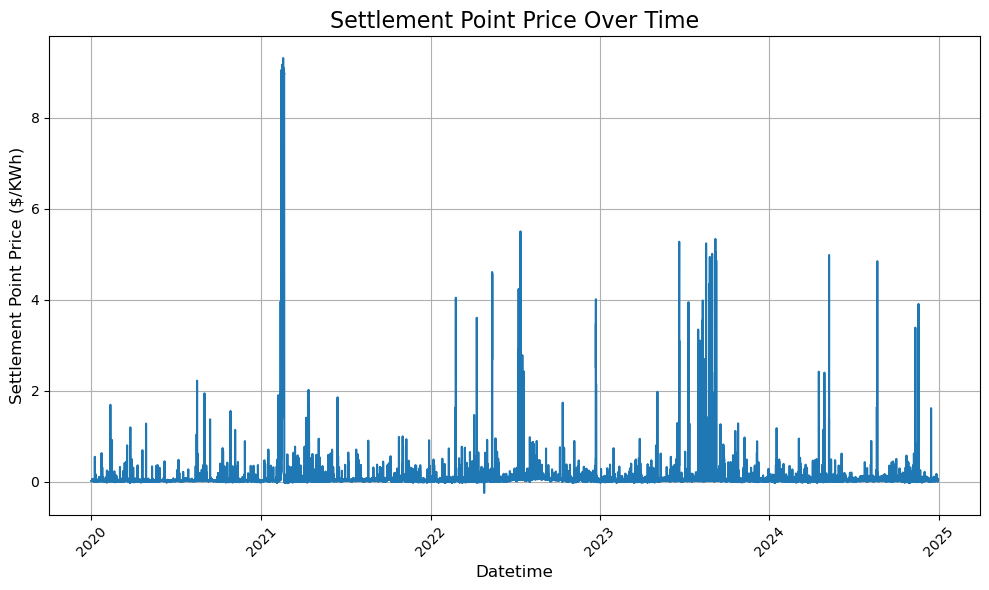

In [106]:
# Sort by the new datetime column
df = rtp_table[rtp_table["Settlement Point Name"] == "HB_WEST"]

df = df.sort_values(by='Datetime')

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df['Datetime'], df['Settlement Point Price']/1000)
plt.title('Settlement Point Price Over Time', fontsize=16)
plt.xlabel('Datetime', fontsize=12)
plt.ylabel('Settlement Point Price ($/KWh)', fontsize=12)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [107]:
avg_hrly_ps = rtp_table.groupby(["Settlement Point Name","Settlement Point Type", "sheet_name", "Delivery Hour"])["Settlement Point Price"].agg(["mean", "median", "min", "max"]).reset_index()
avg_hrly_ps["m_Hour"] = avg_hrly_ps["sheet_name"] + "-" + avg_hrly_ps["Delivery Hour"].astype(int).astype(str)
avg_hrly_ps[avg_hrly_ps["Settlement Point Type"] == "LZ"]

,Settlement Point Name,Settlement Point Type,sheet_name,Delivery Hour,mean,median,min,max,m_Hour
288,LZ_WEST,LZ,Apr,1.0,24.322717,15.530,-25.38,616.57,Apr-1
289,LZ_WEST,LZ,Apr,2.0,22.903417,12.865,-23.47,624.33,Apr-2
290,LZ_WEST,LZ,Apr,3.0,21.221650,12.525,-27.47,628.52,Apr-3
291,LZ_WEST,LZ,Apr,4.0,20.394150,12.065,-29.85,627.62,Apr-4
292,LZ_WEST,LZ,Apr,5.0,21.225850,13.410,-30.72,625.92,Apr-5
...,...,...,...,...,...,...,...,...,...
571,LZ_WEST,LZ,Sep,20.0,154.742200,65.855,13.82,5339.52,Sep-20
572,LZ_WEST,LZ,Sep,21.0,65.919117,48.505,14.10,4744.39,Sep-21
573,LZ_WEST,LZ,Sep,22.0,45.170600,41.495,10.05,293.28,Sep-22
574,LZ_WEST,LZ,Sep,23.0,41.469517,38.570,0.65,117.98,Sep-23


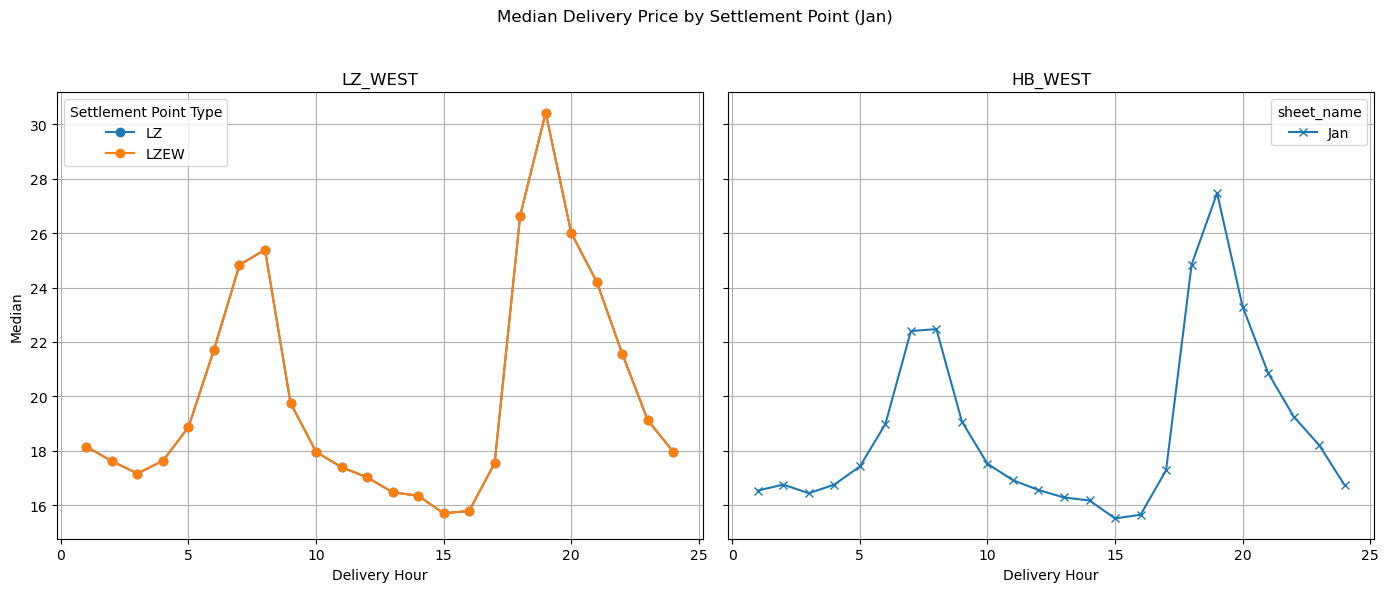

In [108]:
# Pivot the data for easier plotting
pivoted_data = avg_hrly_ps[(avg_hrly_ps["Settlement Point Name"] == "LZ_WEST") & (avg_hrly_ps["sheet_name"] == "Jan")].pivot(index="Delivery Hour", columns="Settlement Point Type", values="median")
pivoted_data2 = avg_hrly_ps[(avg_hrly_ps["Settlement Point Name"] == "HB_WEST") & (avg_hrly_ps["sheet_name"] == "Jan")].pivot(index="Delivery Hour", columns="sheet_name", values="median") 

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
# Plot LZ_WEST on the first subplot
pivoted_data.plot(
    kind="line", ax=axes[0], title="LZ_WEST", legend=True, marker='o'
)
axes[0].set_xlabel("Delivery Hour")
axes[0].set_ylabel("Median")
axes[0].grid(True)

# Plot HB_WEST on the second subplot
pivoted_data2.plot(
    kind="line", ax=axes[1], title="HB_WEST", legend=True, marker='x'
)
axes[1].set_xlabel("Delivery Hour")
axes[1].grid(True)

# Adjust layout
fig.suptitle("Median Delivery Price by Settlement Point (Jan)")
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for overall title
plt.show()

## IREN Revenue from bitcoin mining

In [109]:
## Current Hashprice is $.05723 per th/day
## Iren Fleet is 15 J/TH
## J/KWh is 3600000

hashprice = .05723
efficiency = 15*86400
conv = 3600000

btc_revenue = hashprice*(1/efficiency)*conv

C:\Users\bfass\AppData\Local\Temp\ipykernel_11380\984795629.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rtp_table_month['Datetime Exact'] = pd.to_datetime(rtp_table_month['Datetime Exact'])


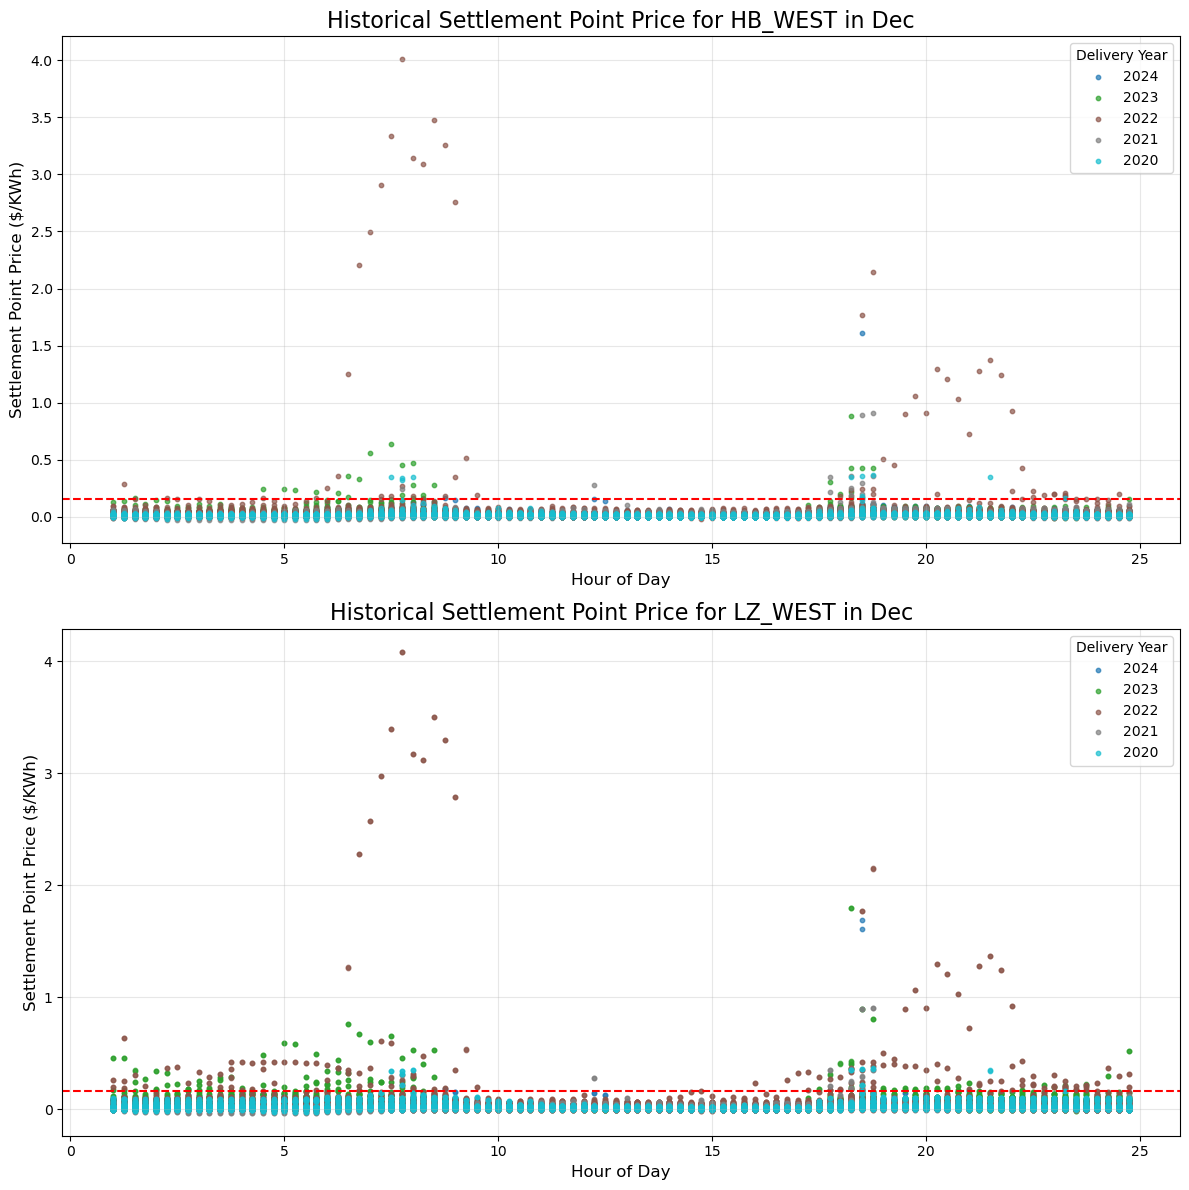

In [110]:
month = 'Dec'

rtp_table_month = rtp_table[rtp_table["sheet_name"] == month]

# Ensure 'Datetime Exact' is in datetime format
rtp_table_month['Datetime Exact'] = pd.to_datetime(rtp_table_month['Datetime Exact'])

# Get unique Settlement Point Names
settlement_points = rtp_table_month['Settlement Point Name'].unique()

# Get unique Delivery_Years and assign colors
unique_years = rtp_table_month['Delivery_Year'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_years)))
year_color_map = dict(zip(unique_years, colors))

# Create subplots
fig, axes = plt.subplots(nrows=len(settlement_points), ncols=1, figsize=(12, 6 * len(settlement_points)))

if len(settlement_points) == 1:
    axes = [axes]  # Ensure axes is iterable when there's only one subplot

# Plot for each Settlement Point Name
for ax, settlement_point in zip(axes, settlement_points):
    subset = rtp_table_month[rtp_table_month['Settlement Point Name'] == settlement_point]
    
    for year in unique_years:
        year_data = subset[subset['Delivery_Year'] == year]
        ax.scatter(
            year_data['Delivery Hour Decimal'],
            year_data['Settlement Point Price'] / 1000,
            color=year_color_map[year],
            label=str(year),
            alpha=0.7,
            s=10  # Marker size
        )
    
    ax.set_title(f"Historical Settlement Point Price for {settlement_point} in {month}", fontsize=16)
    ax.set_xlabel("Hour of Day", fontsize=12)
    ax.set_ylabel("Settlement Point Price ($/KWh)", fontsize=12)
    ax.legend(title="Delivery Year", fontsize=10)
    ax.grid(alpha=0.3)

    ax.axhline(y=btc_revenue, color='red', linestyle='--', linewidth=1.5, label=f"IREN Revenue: {btc_revenue:.2f} $/KWh")
# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


## DAM Prices

In [111]:
dam_table["Num_Hour"] = dam_table["Hour Ending"].str.split(":").str[0].astype(int)
dam_table["Delivery Date"] = pd.to_datetime(dam_table["Delivery Date"])
dam_table["Delivery_Year"] = dam_table["Delivery Date"].dt.year
dam_table

,Unnamed: 0,Delivery Date,Hour Ending,Repeated Hour Flag,Settlement Point,Settlement Point Price,source_file,excel_file,sheet_name,Num_Hour,Delivery_Year
0,6,2024-01-01,01:00,N,HB_WEST,19.79,2.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2024....,Jan,1,2024
1,14,2024-01-01,01:00,N,LZ_WEST,26.93,2.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2024....,Jan,1,2024
2,21,2024-01-01,02:00,N,HB_WEST,20.90,2.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2024....,Jan,2,2024
3,29,2024-01-01,02:00,N,LZ_WEST,28.04,2.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2024....,Jan,2,2024
4,36,2024-01-01,03:00,N,HB_WEST,21.34,2.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2024....,Jan,3,2024
...,...,...,...,...,...,...,...,...,...,...,...
87691,657689,2020-12-31,22:00,N,LZ_WEST,26.07,5.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2020....,Dec,22,2020
87692,657696,2020-12-31,23:00,N,HB_WEST,24.31,5.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2020....,Dec,23,2020
87693,657704,2020-12-31,23:00,N,LZ_WEST,25.67,5.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2020....,Dec,23,2020
87694,657711,2020-12-31,24:00,N,HB_WEST,23.45,5.zip,rpt.00013060.0000000000000000.DAMLZHBSPP_2020....,Dec,24,2020


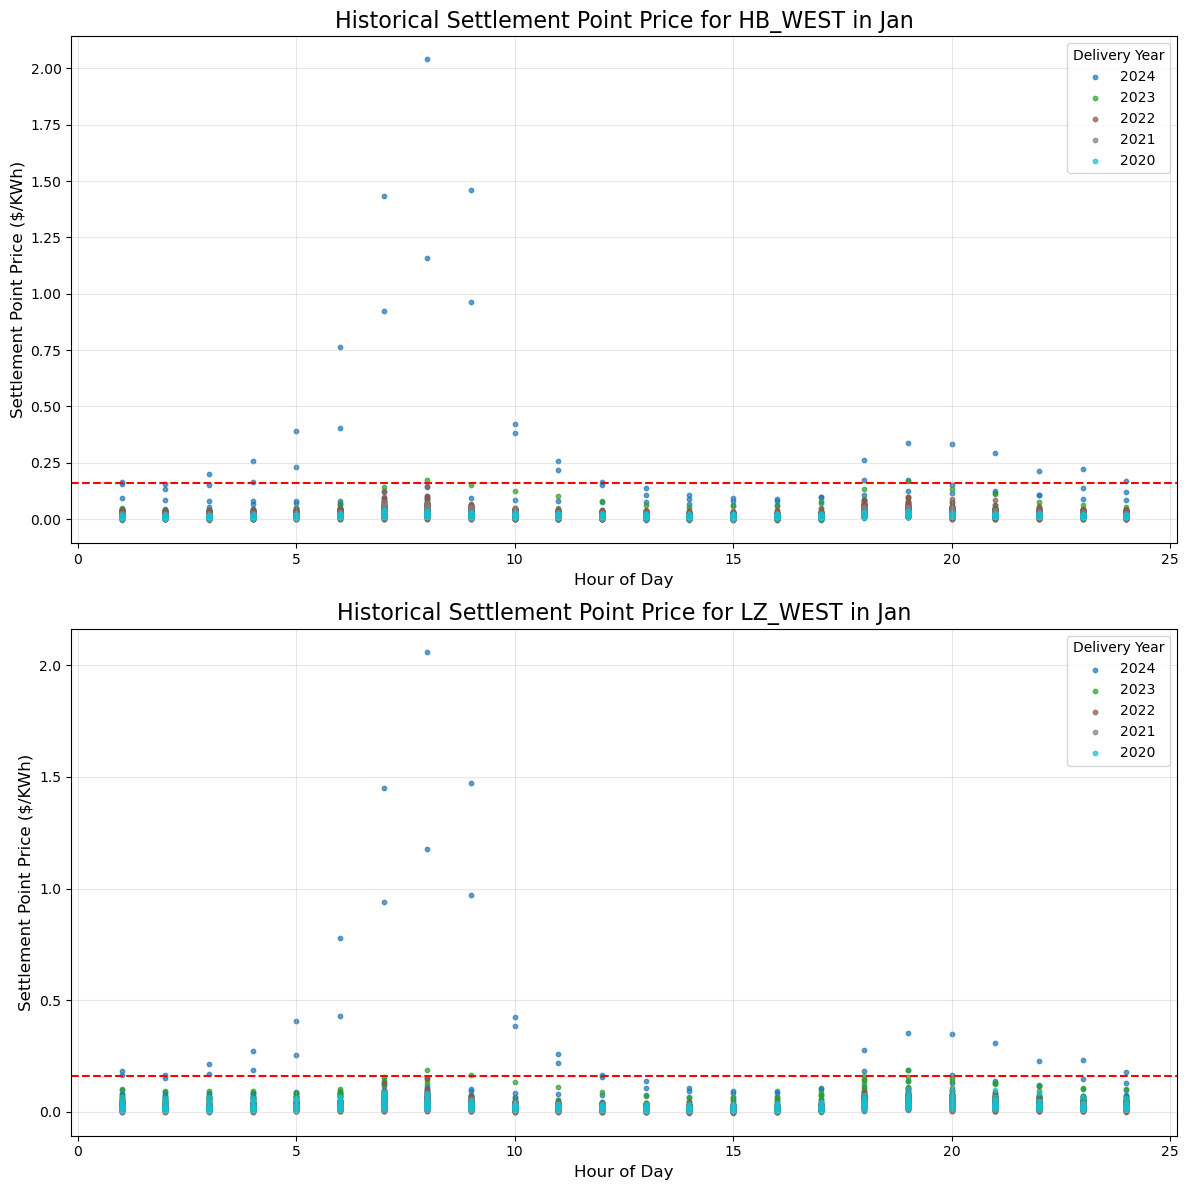

In [112]:
month = 'Jan'

dam_table_month = dam_table[dam_table["sheet_name"] == month]

# Get unique Settlement Point Names
settlement_points = dam_table_month['Settlement Point'].unique()

# Get unique Delivery_Years and assign colors
unique_years = dam_table_month['Delivery_Year'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_years)))
year_color_map = dict(zip(unique_years, colors))

# Create subplots
fig, axes = plt.subplots(nrows=len(settlement_points), ncols=1, figsize=(12, 6 * len(settlement_points)))

if len(settlement_points) == 1:
    axes = [axes]  # Ensure axes is iterable when there's only one subplot

# Plot for each Settlement Point Name
for ax, settlement_point in zip(axes, settlement_points):
    subset = dam_table_month[dam_table_month['Settlement Point'] == settlement_point]
    
    for year in unique_years:
        year_data = subset[subset['Delivery_Year'] == year]
        ax.scatter(
            year_data['Num_Hour'],
            year_data['Settlement Point Price'] / 1000,
            color=year_color_map[year],
            label=str(year),
            alpha=0.7,
            s=10  # Marker size
        )
    
    ax.set_title(f"Historical Settlement Point Price for {settlement_point} in {month}", fontsize=16)
    ax.set_xlabel("Hour of Day", fontsize=12)
    ax.set_ylabel("Settlement Point Price ($/KWh)", fontsize=12)
    ax.legend(title="Delivery Year", fontsize=10)
    ax.grid(alpha=0.3)

    ax.axhline(y=btc_revenue, color='red', linestyle='--', linewidth=1.5, label=f"IREN Revenue: {btc_revenue:.2f} $/KWh")

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Prices by Hub

In [113]:
hub = pd.read_csv("Childress_LMP.csv")

In [114]:
hub[hub["SettlementPoint"] == "CHIL_SLR"]

,Unnamed: 0,SCEDTimestamp,RepeatedHourFlag,SettlementPoint,LMP,source_file,csv_file
179,179,01/02/2025 00:00:11,N,CHIL_SLR,19.62,cdr.00012300.0000000000000000.20250102.0000149...,cdr.00012300.0000000000000000.20250102.000014....
1130,1130,01/02/2025 00:05:10,N,CHIL_SLR,19.62,cdr.00012300.0000000000000000.20250102.0005151...,cdr.00012300.0000000000000000.20250102.000513....
2081,2081,01/02/2025 00:10:11,N,CHIL_SLR,19.64,cdr.00012300.0000000000000000.20250102.0010139...,cdr.00012300.0000000000000000.20250102.001013....
3032,3032,01/02/2025 00:15:11,N,CHIL_SLR,19.73,cdr.00012300.0000000000000000.20250102.0015143...,cdr.00012300.0000000000000000.20250102.001513....
3983,3983,01/02/2025 00:20:10,N,CHIL_SLR,20.05,cdr.00012300.0000000000000000.20250102.0020123...,cdr.00012300.0000000000000000.20250102.002012....
...,...,...,...,...,...,...,...
1608320,1608320,01/06/2025 21:05:10,N,CHIL_SLR,38.50,mirDownload (25).zip,cdr.00012300.0000000000000000.20250106.210512....
1609271,1609271,01/07/2025 20:45:09,N,CHIL_SLR,31.94,mirDownload (3).zip,cdr.00012300.0000000000000000.20250107.204511....
1610222,1610222,01/07/2025 20:40:10,N,CHIL_SLR,31.63,mirDownload (4).zip,cdr.00012300.0000000000000000.20250107.204011....
1611173,1611173,01/07/2025 20:35:09,N,CHIL_SLR,31.54,mirDownload (5).zip,cdr.00012300.0000000000000000.20250107.203511....


In [115]:
hub["SCEDTimestamp"] = pd.to_datetime(hub["SCEDTimestamp"])

In [116]:
hub["Date"] = hub["SCEDTimestamp"].dt.date

In [117]:
hub["Date"].value_counts()

Date
2025-01-06    276741
2025-01-02    274839
2025-01-03    273888
2025-01-04    273888
2025-01-05    273888
2025-01-07    239652
Name: count, dtype: int64

In [118]:
hub["Date"] = pd.to_datetime(hub["Date"])

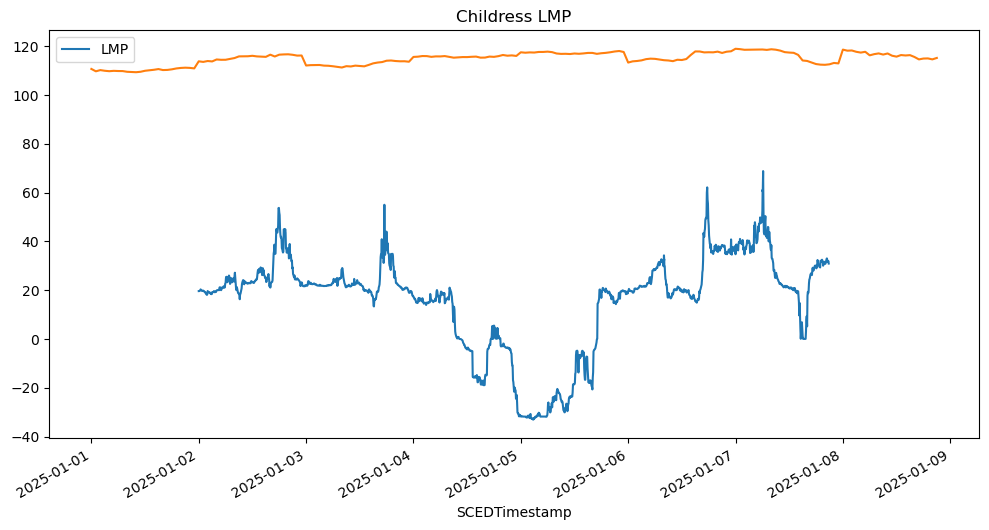

In [119]:
hub[(hub["SettlementPoint"] == "CHIL_SLR")].sort_values(by="SCEDTimestamp").plot(x="SCEDTimestamp", y="LMP", title="Childress LMP", figsize=(12, 6))


btc_tbl["Datetime"] = pd.to_datetime(btc_tbl["Datetime"])
btc_tbl["Date"] = pd.to_datetime(btc_tbl["Date"])
btc_tbl["Hour"] = pd.to_datetime(btc_tbl["Datetime"]).dt.hour + 1

tst_btc = btc_tbl[btc_tbl["Date"] >= "2025-01-01"]
plt.plot(tst_btc["Datetime"], tst_btc["Revenue_KWh"]*1000)
# 'CHIL_SLR'
# 'SWEETWN2_2_4', 'SWEETWN3_3', 'SWEETWND_1'

In [120]:
btc_tbl

,Unnamed: 0,Datetime,Date,Close,Tx_Fees_BTC,Hash Rate (TH/s),EST_TX_Fees_Per_Block,Block_Reward,Total_Block_Reward,Hash_Price_THs_day,Revenue_KWh,Hour
0,46,2023-01-11 00:00:00+00:00,2023-01-11,17473.570312,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.058063,0.120965,1
1,47,2023-01-11 01:00:00+00:00,2023-01-11,17464.119141,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.058032,0.120900,2
2,48,2023-01-11 02:00:00+00:00,2023-01-11,17420.416016,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.057887,0.120597,3
3,49,2023-01-11 03:00:00+00:00,2023-01-11,17421.119141,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.057889,0.120602,4
4,50,2023-01-11 04:00:00+00:00,2023-01-11,17415.287109,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.057870,0.120562,5
...,...,...,...,...,...,...,...,...,...,...,...,...
17404,17450,2025-01-08 17:00:00+00:00,2025-01-08,93927.953125,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055006,0.114595,18
17405,17451,2025-01-08 18:00:00+00:00,2025-01-08,94212.679688,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055172,0.114942,19
17406,17452,2025-01-08 19:00:00+00:00,2025-01-08,94258.359375,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055199,0.114998,20
17407,17453,2025-01-08 20:00:00+00:00,2025-01-08,93937.093750,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055011,0.114606,21


## Margins and Curtailment Time in December

In [298]:
month = 'Aug'
year = 2023

In [299]:
dec_rtp_table = rtp_table[
    (rtp_table["Delivery_Year"] == year) & (rtp_table["sheet_name"] == month) & (rtp_table["Settlement Point Name"] == "LZ_WEST")
].rename(columns={"Settlement Point Price": "Settlement Price RTP"})

dec_dam_table = dam_table[
    (dam_table["Delivery_Year"] == year) & (dam_table["sheet_name"] == month) & (dam_table["Settlement Point"] == "LZ_WEST")
].rename(columns={"Settlement Point Price": "Settlement Price DAM", "Num_Hour":"Delivery Hour"})


btc_tbl["Datetime"] = pd.to_datetime(btc_tbl["Datetime"])
btc_tbl["Date"] = pd.to_datetime(btc_tbl["Date"])
btc_tbl["Hour"] = pd.to_datetime(btc_tbl["Datetime"]).dt.hour + 1


tbl = dec_rtp_table[["Delivery Date", "Delivery Hour", "Delivery Interval", "Settlement Price RTP"]].merge(dec_dam_table[["Delivery Date", "Delivery Hour", "Settlement Price DAM"]], how="left", on=["Delivery Date", "Delivery Hour"])
tbl["Delivery Date"] = pd.to_datetime(tbl["Delivery Date"])
tbl = tbl.merge(btc_tbl[["Date", "Hour", "Close", "Revenue_KWh","Hash_Price_THs_day"]], how = "left", right_on=["Date", "Hour"], left_on=["Delivery Date", "Delivery Hour"])

tbl["Settlement Price RTP"] = tbl["Settlement Price RTP"] / 1000
tbl["Settlement Price DAM"] = tbl["Settlement Price DAM"] / 1000

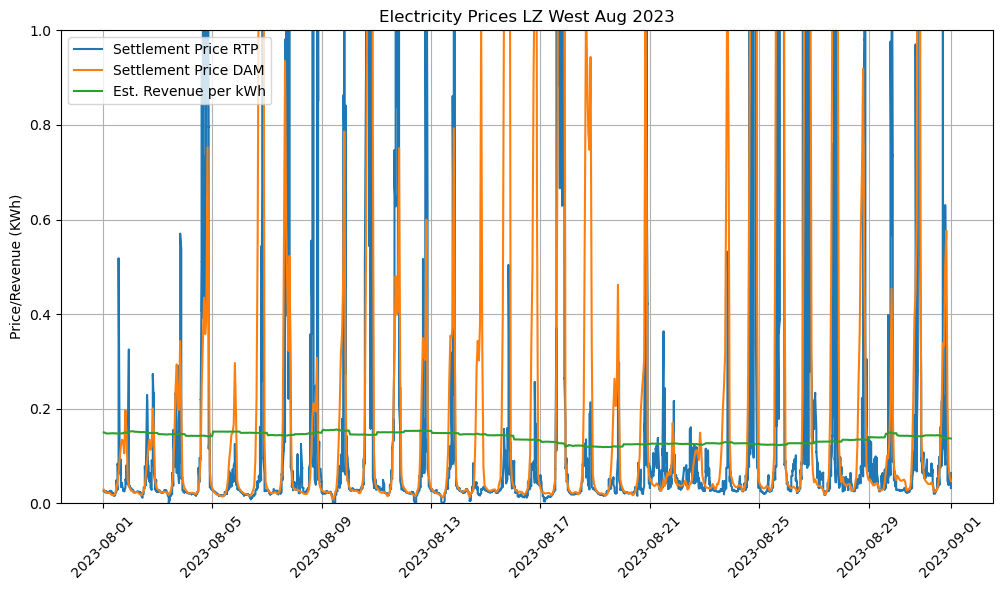

In [300]:
import matplotlib.pyplot as plt

# Combine Delivery Date and Hour into a single datetime column
tbl["Datetime"] = tbl["Delivery Date"] + pd.to_timedelta(tbl["Delivery Hour"], unit="h")

# Plot the data
plt.figure(figsize=(10, 6))

# Plot Settlement Price RTP
plt.plot(tbl["Datetime"], tbl["Settlement Price RTP"], label="Settlement Price RTP")

# Plot Settlement Price DAM
plt.plot(tbl["Datetime"], tbl["Settlement Price DAM"], label="Settlement Price DAM")

# Plot Revenue_KWh
plt.plot(tbl["Datetime"], tbl["Revenue_KWh"], label="Est. Revenue per kWh")

# Customize plot
plt.title(f"Electricity Prices LZ West {month} {year}")
#plt.xlabel("Datetime")
plt.ylabel("Price/Revenue (KWh)")
plt.legend(loc="upper left")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.ylim(top=1) 
plt.ylim(0) 
# Show plot
plt.show()


In [301]:
tbl["Settlement Price DAM"].mean()

0.2675786827956989

In [302]:
tbl["Settlement Price RTP"].mean() #* 1000 * 421 * 24 * 31

0.19918282258064515

In [ ]:
* 1000 * 421 * 24 * 31

In [273]:
tbl[tbl["Settlement Price RTP"] < tbl["Revenue_KWh"]]["Settlement Price RTP"].mean() * 1000 * 421 * 24 * 31

12629686.738157304

In [259]:
tbl[tbl["Settlement Price RTP"] > .07]["Settlement Price RTP"].mean()

0.09374646900269541

In [260]:
tbl[tbl["Settlement Price RTP"] > .07]["Settlement Price RTP"].count() / 4

185.5

In [303]:
tbl[tbl["Settlement Price RTP"] >= tbl["Revenue_KWh"]]["Settlement Price RTP"].count()

879

In [265]:
tbl["Hash_Price_THs_day"].mean() * 1000000 * 28.1 * 31

51968304.762985334

In [252]:
tbl

,Delivery Date,Delivery Hour,Delivery Interval,Settlement Price RTP,Settlement Price DAM,Date,Hour,Close,Revenue_KWh,Datetime
0,2024-12-01,1.0,1.0,0.03932,0.04231,2024-12-01,1,96381.835938,0.130735,2024-12-01 01:00:00
1,2024-12-01,1.0,1.0,0.03933,0.04231,2024-12-01,1,96381.835938,0.130735,2024-12-01 01:00:00
2,2024-12-01,1.0,2.0,0.03566,0.04231,2024-12-01,1,96381.835938,0.130735,2024-12-01 01:00:00
3,2024-12-01,1.0,2.0,0.03566,0.04231,2024-12-01,1,96381.835938,0.130735,2024-12-01 01:00:00
4,2024-12-01,1.0,3.0,0.03453,0.04231,2024-12-01,1,96381.835938,0.130735,2024-12-01 01:00:00
...,...,...,...,...,...,...,...,...,...,...
5371,2024-12-28,24.0,2.0,0.06537,0.06405,2024-12-28,24,95204.757812,0.118559,2024-12-29 00:00:00
5372,2024-12-28,24.0,3.0,0.06084,0.06405,2024-12-28,24,95204.757812,0.118559,2024-12-29 00:00:00
5373,2024-12-28,24.0,3.0,0.06083,0.06405,2024-12-28,24,95204.757812,0.118559,2024-12-29 00:00:00
5374,2024-12-28,24.0,4.0,0.04137,0.06405,2024-12-28,24,95204.757812,0.118559,2024-12-29 00:00:00


In [242]:
169/(4*24)

1.7604166666666667

## A view on energy volatility

In [197]:
year = 2024

filtered_rtp = rtp_table[(rtp_table["Delivery_Year"] != year) & (rtp_table["Settlement Point Name"] == "LZ_WEST")]
filtered_rtp_other = rtp_table[(rtp_table["Delivery_Year"] == year) & (rtp_table["Settlement Point Name"] == "LZ_WEST")]

In [198]:
mean_rtp = filtered_rtp.groupby(["sheet_name"])["Settlement Point Price"].mean().reset_index()

#filtered_rtp.groupby(["sheet_name"])["Settlement Point Price"].agg(["median", "min", "max"]).reset_index()

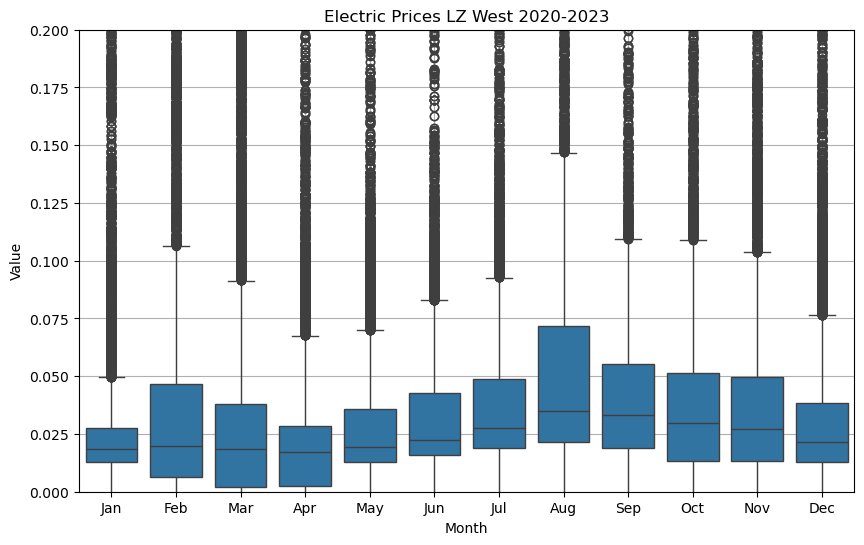

In [ ]:
# Create a grouped box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="sheet_name", y="Settlement Point Price KWH", data=filtered_rtp)

# Customize the plot
plt.title("Electric Prices LZ West 2020-2023")
plt.xlabel("Month")
plt.ylabel("Value")
plt.ylim(top=.2) 
plt.ylim(0) 
plt.grid(True)
plt.show()

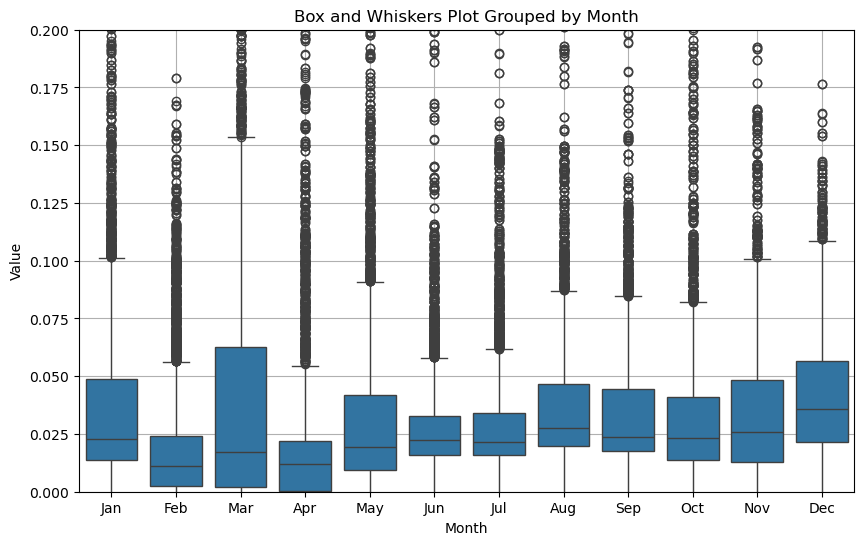

In [202]:
# Create a grouped box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="sheet_name", y="Settlement Point Price KWH", data=filtered_rtp_other)

# Customize the plot
plt.title("Box and Whiskers Plot Grouped by Month")
plt.xlabel("Month")
plt.ylabel("Value")
plt.ylim(top=.2) 
plt.ylim(0) 
plt.grid(True)
plt.show()

C:\Users\bfass\AppData\Local\Temp\ipykernel_11380\1524034479.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rtp["Dataset"] = "2020-2023"
C:\Users\bfass\AppData\Local\Temp\ipykernel_11380\1524034479.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_rtp_other["Dataset"] = "2024"


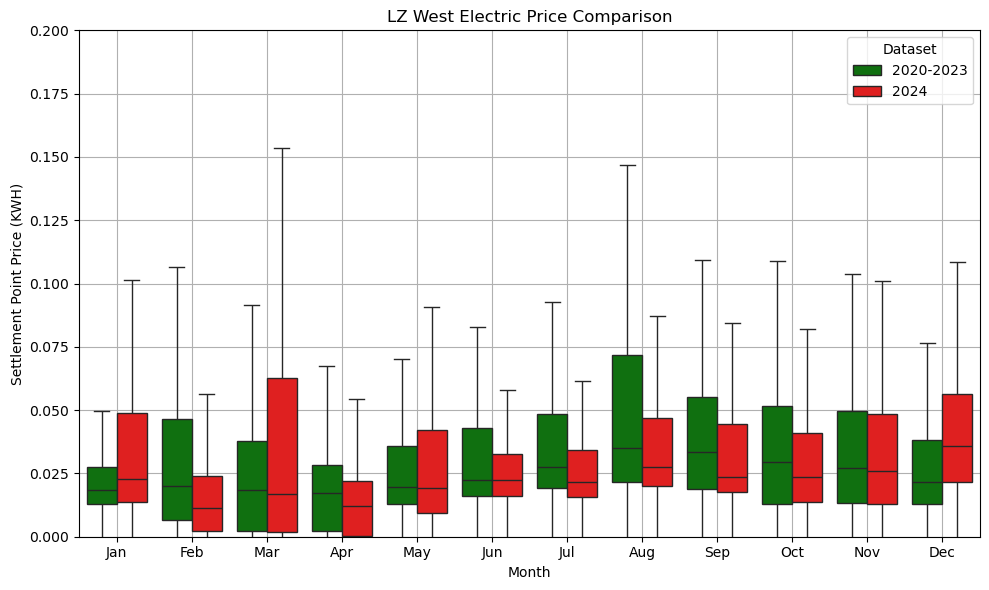

In [279]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add a column to distinguish the datasets
filtered_rtp["Dataset"] = "2020-2023"
filtered_rtp_other["Dataset"] = "2024"

# Combine the two datasets into one DataFrame
combined_data = pd.concat([filtered_rtp, filtered_rtp_other])

# Create a grouped box plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="sheet_name", 
    y="Settlement Point Price KWH", 
    hue="Dataset",  # Use the 'Dataset' column to separate the groups
    data=combined_data, 
    showfliers=False,  # Exclude outliers
    palette={"2020-2023": "green", "2024": "red"}  # Assign colors
)

# Customize the plot
plt.title("LZ West Electric Price Comparison")
plt.xlabel("Month")
plt.ylabel("Settlement Point Price (KWH)")
plt.ylim(0, 0.2)  # Set y-axis limits
plt.grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


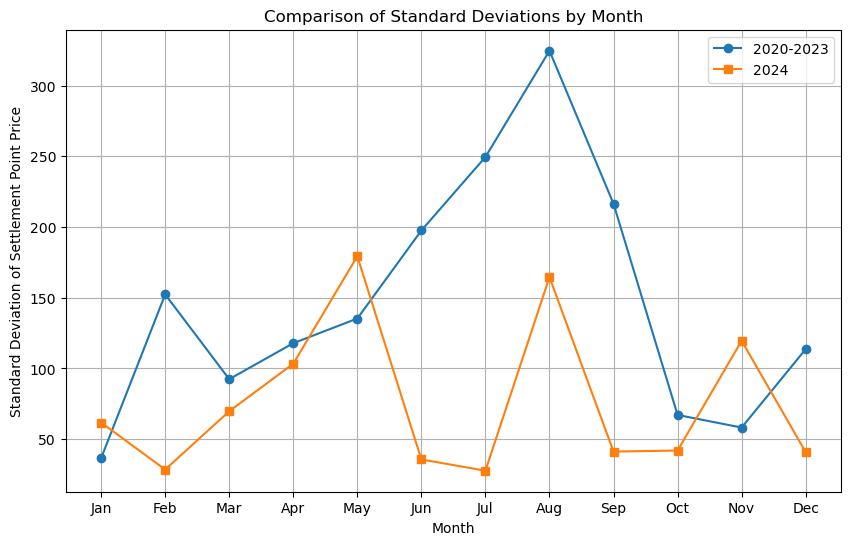

In [ ]:
std1 = filtered_rtp[(filtered_rtp["Delivery_Year"] != 2021) | (filtered_rtp["sheet_name"] != "Feb")].groupby(["sheet_name"])["Settlement Point Price"].std().reset_index()
std2 = filtered_rtp_other.groupby(["sheet_name"])["Settlement Point Price"].std().reset_index()


# List of months in the correct order (3-character abbreviations)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Convert 'sheet_name' to a categorical type with the correct order
std1["sheet_name"] = pd.Categorical(std1["sheet_name"], categories=month_order, ordered=True)
std2["sheet_name"] = pd.Categorical(std2["sheet_name"], categories=month_order, ordered=True)

# Sort the DataFrames by the month order
std1 = std1.sort_values("sheet_name")
std2 = std2.sort_values("sheet_name")

# Plot setup
plt.figure(figsize=(10, 6))

# Plot the first dataset
plt.plot(std1["sheet_name"], std1["Settlement Point Price"], label="2020-2023", marker="o")

# Plot the second dataset
plt.plot(std2["sheet_name"], std2["Settlement Point Price"], label="2024", marker="s")

# Add labels and title
plt.title("Comparison of Standard Deviations by Month")
plt.xlabel("Month")
plt.ylabel("Standard Deviation of Settlement Point Price")
plt.legend()
plt.grid(True)

# Rotate x-axis labels for better r


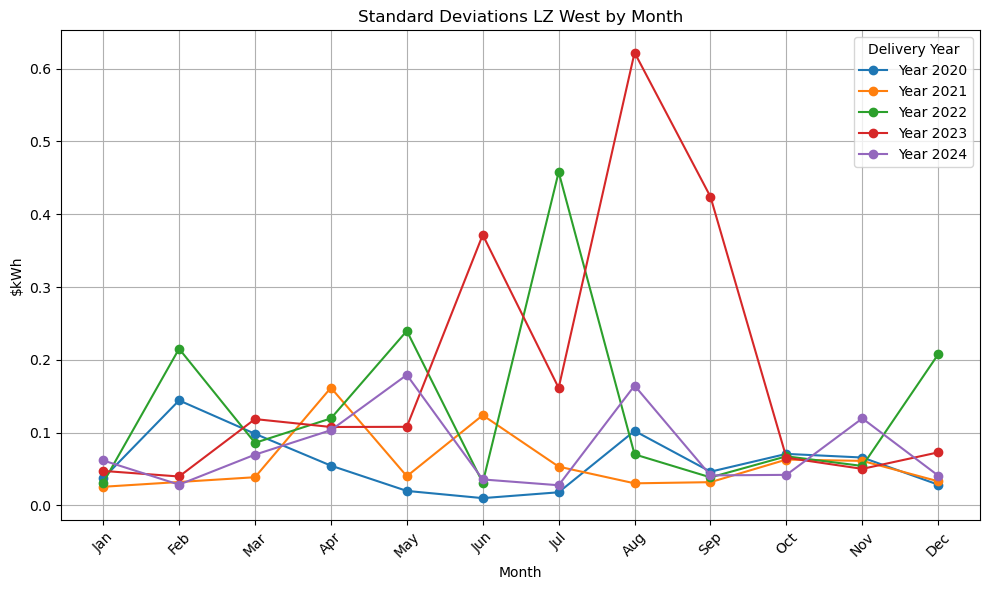

In [290]:
Vol_by_year = rtp_table[((rtp_table["Delivery_Year"] != 2021) | (rtp_table["sheet_name"] != "Feb")) & (rtp_table["Settlement Point Name"] == "LZ_WEST")].groupby(["Delivery_Year", "sheet_name"])["Settlement Point Price KWH"].std().reset_index()


import pandas as pd
import matplotlib.pyplot as plt

# Example: List of months in the correct order (3-character abbreviations)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Ensure 'sheet_name' is a categorical variable with the correct order
Vol_by_year["sheet_name"] = pd.Categorical(
    Vol_by_year["sheet_name"], categories=month_order, ordered=True
)

# Sort the DataFrame by 'Delivery_Year' and 'sheet_name'
Vol_by_year = Vol_by_year.sort_values(["Delivery_Year", "sheet_name"])

# Plot setup
plt.figure(figsize=(10, 6))

# Loop through each unique Delivery_Year
for year in Vol_by_year["Delivery_Year"].unique():
    # Filter the data for the current year
    year_data = Vol_by_year[Vol_by_year["Delivery_Year"] == year]
    
    # Plot the data for the current year
    plt.plot(
        year_data["sheet_name"], 
        year_data["Settlement Point Price KWH"], 
        label=f"Year {year}", 
        marker="o"
    )

# Add labels, legend, and title
plt.title("Standard Deviations LZ West by Month")
plt.xlabel("Month")
plt.ylabel("$kWh")
plt.legend(title="Delivery Year")
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


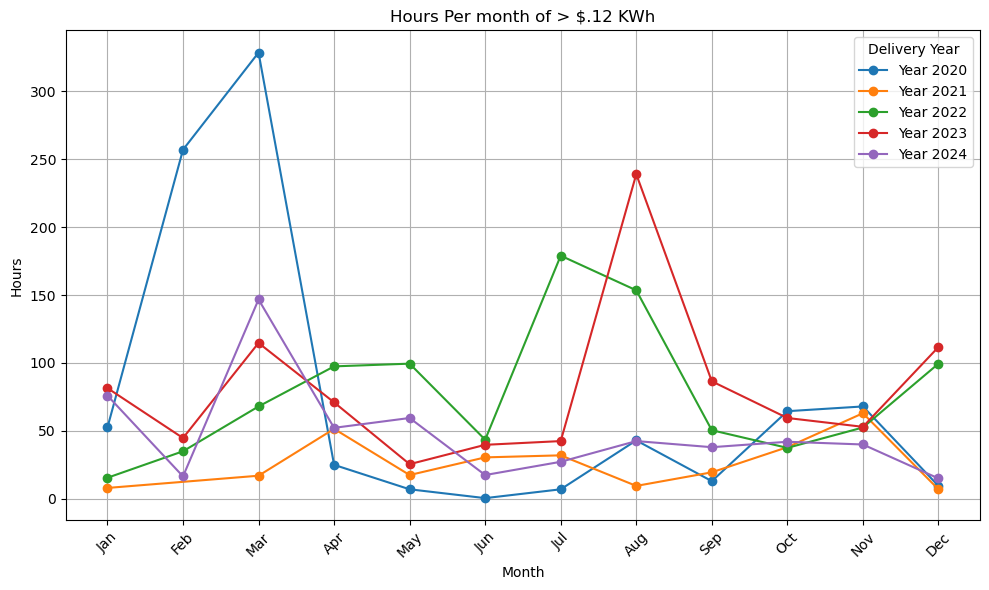

In [306]:
Vol_by_year = rtp_table[((rtp_table["Delivery_Year"] != 2021) | (rtp_table["sheet_name"] != "Feb")) & (rtp_table["Settlement Point Name"] == "LZ_WEST")]
Vol_by_year = Vol_by_year.merge(btc_tbl[["Date", "Hour", "Close", "Revenue_KWh"]], how = "left", left_on=["Delivery Date", "Delivery Hour"], right_on=["Date", "Hour"])
Vol_by_year["Settlement Point Price KWH"] = Vol_by_year["Settlement Point Price"] / 1000
Vol_by_year = Vol_by_year[Vol_by_year["Settlement Point Price KWH"] >= .12].groupby(["Delivery_Year", "sheet_name"])["Settlement Point Price KWH"].count().reset_index() 
Vol_by_year["Settlement Point Price KWH"] = Vol_by_year["Settlement Point Price KWH"] / 4

import pandas as pd
import matplotlib.pyplot as plt

# Example: List of months in the correct order (3-character abbreviations)
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Ensure 'sheet_name' is a categorical variable with the correct order
Vol_by_year["sheet_name"] = pd.Categorical(
    Vol_by_year["sheet_name"], categories=month_order, ordered=True
)

# Sort the DataFrame by 'Delivery_Year' and 'sheet_name'
Vol_by_year = Vol_by_year.sort_values(["Delivery_Year", "sheet_name"])

# Plot setup
plt.figure(figsize=(10, 6))

# Loop through each unique Delivery_Year
for year in Vol_by_year["Delivery_Year"].unique():
    # Filter the data for the current year
    year_data = Vol_by_year[Vol_by_year["Delivery_Year"] == year]
    
    # Plot the data for the current year
    plt.plot(
        year_data["sheet_name"], 
        year_data["Settlement Point Price KWH"], 
        label=f"Year {year}", 
        marker="o"
    )

# Add labels, legend, and title
plt.title("Hours Per month of > $.12 KWh")
plt.xlabel("Month")
plt.ylabel("Hours")
plt.legend(title="Delivery Year")
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [296]:
btc_tbl 

,Unnamed: 0,Datetime,Date,Close,Tx_Fees_BTC,Hash Rate (TH/s),EST_TX_Fees_Per_Block,Block_Reward,Total_Block_Reward,Hash_Price_THs_day,Revenue_KWh,Hour
0,46,2023-01-11 00:00:00+00:00,2023-01-11,17473.570312,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.058063,0.120965,1
1,47,2023-01-11 01:00:00+00:00,2023-01-11,17464.119141,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.058032,0.120900,2
2,48,2023-01-11 02:00:00+00:00,2023-01-11,17420.416016,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.057887,0.120597,3
3,49,2023-01-11 03:00:00+00:00,2023-01-11,17421.119141,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.057889,0.120602,4
4,50,2023-01-11 04:00:00+00:00,2023-01-11,17415.287109,10.081381,2.738798e+08,0.070010,6.250,6.320010,0.057870,0.120562,5
...,...,...,...,...,...,...,...,...,...,...,...,...
17404,17450,2025-01-08 17:00:00+00:00,2025-01-08,93927.953125,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055006,0.114595,18
17405,17451,2025-01-08 18:00:00+00:00,2025-01-08,94212.679688,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055172,0.114942,19
17406,17452,2025-01-08 19:00:00+00:00,2025-01-08,94258.359375,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055199,0.114998,20
17407,17453,2025-01-08 20:00:00+00:00,2025-01-08,93937.093750,6.370102,7.793020e+08,0.044237,3.125,3.169237,0.055011,0.114606,21
